In [1]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"ayaalfarekh","key":"17e64e7a636ed2f80a8d3eb0f979f115"}'}

In [2]:
!mkdir -p ~/.kaggle
!mv "kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d evilspirit05/ecg-analysis --unzip

Dataset URL: https://www.kaggle.com/datasets/evilspirit05/ecg-analysis
License(s): MIT
 99% 0.98G/1.00G [00:12<00:00, 98.7MB/s]
100% 1.00G/1.00G [00:12<00:00, 86.3MB/s]


استدعاء المكاتب

In [35]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import stats
from collections import Counter
import seaborn as sns
from sklearn.svm import SVC
from skimage.feature import local_binary_pattern, hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


تحويل اسم الكلاس لرقم (label)

In [5]:
class_names = ['MI', 'PMI', 'HB', 'Normal']
class_name_label = {name: i for i, name in enumerate(class_names)}

def get_label_from_folder(folder_name):
    folder_name = folder_name.lower()
    if "abnormal_heartbeat" in folder_name:
        return class_name_label['HB']
    elif "post_mi_history" in folder_name:
        return class_name_label['PMI']
    elif "myocardial_infarction" in folder_name:
        return class_name_label['MI']
    elif "normal" in folder_name:
        return class_name_label['Normal']
    else:
        return None


بيحول صور ECG into vector features

In [6]:
def extract_all_features(image):
    features = []


    features += [
        np.mean(image),
        np.std(image),
        np.min(image),
        np.max(image)
    ]


    hist, _ = np.histogram(image, bins=16, range=(0,256))
    hist = hist / hist.sum()
    features += hist.tolist()


    lbp = local_binary_pattern(image, P=16, R=2, method='uniform')
    lbp_hist, _ = np.histogram(lbp, bins=18, range=(0,18))
    lbp_hist = lbp_hist / lbp_hist.sum()
    features += lbp_hist.tolist()


    hog_feat = hog(
        image,
        orientations=9,
        pixels_per_cell=(16,16),
        cells_per_block=(2,2),
        visualize=False
    )
    features += hog_feat[:50].tolist()


    edges = cv2.Canny(image, 50, 150)
    features.append(np.sum(edges > 0) / edges.size)

    h_proj = np.sum(image, axis=1)
    v_proj = np.sum(image, axis=0)
    features += [
        np.mean(h_proj), np.std(h_proj),
        np.mean(v_proj), np.std(v_proj)
    ]

    return np.array(features)


load data and preprocessing

In [7]:
BASE_PATH = "/content/ecg_data_new_version/ecg data new version"

def load_data(base_path):
    X, y = [], []

    for folder in os.listdir(base_path):
        folder_path = os.path.join(base_path, folder)
        if not os.path.isdir(folder_path):
            continue

        label = get_label_from_folder(folder)
        if label is None:
            continue

        for file in tqdm(os.listdir(folder_path), desc=f"Loading {folder}"):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path)
            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, (256, 128))

            features = extract_all_features(gray)

            X.append(features)
            y.append(label)

    return np.array(X), np.array(y)

X, y = load_data(BASE_PATH)




Loading normal_ecg_images: 100%|██████████| 284/284 [00:14<00:00, 19.75it/s]


In [8]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (928, 93)
y shape: (928,)


In [23]:
class_names = ['MI', 'PMI', 'HB', 'Normal']

for cls, count in Counter(y).items():
    print(f"{class_names[cls]}: {count} samples")


MI: 239 samples
PMI: 172 samples
HB: 233 samples
Normal: 284 samples


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


Random forest


Test1

In [12]:
model = RandomForestClassifier(
    max_depth=7,
    n_estimators=200,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 0.931266846361186
 Accuracy  on Test: 0.8870967741935484


Test2

In [13]:
model = RandomForestClassifier(
    max_depth=5,
    n_estimators=300,
    min_samples_leaf=10,
    min_samples_split=20,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 0.8355795148247979
 Accuracy  on Test: 0.8118279569892473


Test3

In [14]:
model = RandomForestClassifier(
    max_depth=4,
    n_estimators=200,
    min_samples_leaf=7,
    min_samples_split=12,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 0.8113207547169812
 Accuracy  on Test: 0.7903225806451613


Test4

In [15]:
model = RandomForestClassifier(
    max_depth=7,
    n_estimators=200,
    min_samples_leaf=10,
    min_samples_split=15,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 0.8854447439353099
 Accuracy  on Test: 0.8494623655913979


Test5

In [18]:
model=RandomForestClassifier(n_estimators=300,max_depth=20, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 1.0
 Accuracy  on Test: 0.9623655913978495



Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       0.97      1.00      0.99        34
           2       0.95      0.89      0.92        47
           3       0.93      0.96      0.95        57

    accuracy                           0.96       186
   macro avg       0.96      0.96      0.96       186
weighted avg       0.96      0.96      0.96       186


Confusion Matrix:
 [[48  0  0  0]
 [ 0 34  0  0]
 [ 0  1 42  4]
 [ 0  0  2 55]]


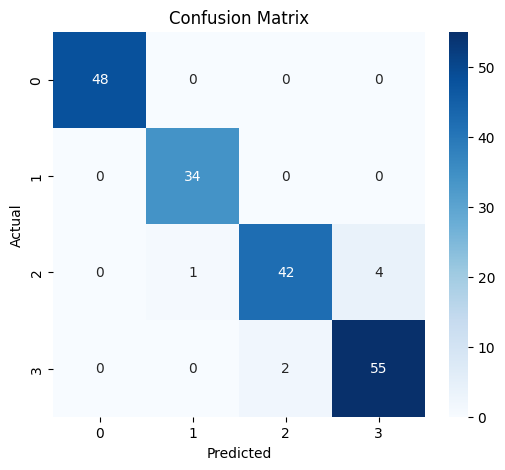

In [20]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


GradientBoosting

test6

In [26]:
model=GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 1.0
 Accuracy  on Test: 0.946236559139785


Test7

In [27]:
model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 1.0
 Accuracy  on Test: 0.9516129032258065


test8

In [30]:
model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=2,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 0.9986522911051213
 Accuracy  on Test: 0.9301075268817204


test9

In [32]:
model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=2,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 1.0
 Accuracy  on Test: 0.9408602150537635


test7

In [33]:
model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 1.0
 Accuracy  on Test: 0.9516129032258065



Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        48
           1       0.97      0.94      0.96        34
           2       0.95      0.89      0.92        47
           3       0.93      0.96      0.95        57

    accuracy                           0.95       186
   macro avg       0.95      0.95      0.95       186
weighted avg       0.95      0.95      0.95       186


Confusion Matrix:
 [[48  0  0  0]
 [ 2 32  0  0]
 [ 0  1 42  4]
 [ 0  0  2 55]]


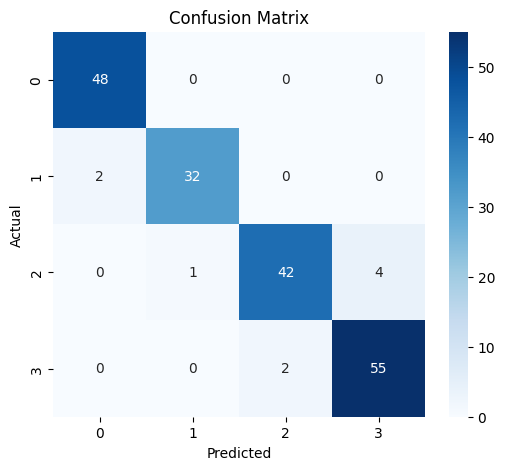

In [34]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


SVM

test10

In [37]:
model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 0.8652291105121294
 Accuracy  on Test: 0.8064516129032258


test11

In [39]:
model = SVC(kernel='rbf', C=0.8, gamma='scale', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 0.8557951482479784
 Accuracy  on Test: 0.7849462365591398


test12

In [40]:
model = SVC(kernel='rbf', C=0.8, gamma='auto', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 0.8557951482479784
 Accuracy  on Test: 0.7849462365591398



Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.96      0.89        48
           1       0.67      0.47      0.55        34
           2       0.88      0.74      0.80        47
           3       0.73      0.86      0.79        57

    accuracy                           0.78       186
   macro avg       0.78      0.76      0.76       186
weighted avg       0.78      0.78      0.78       186


Confusion Matrix:
 [[46  0  0  2]
 [ 4 16  3 11]
 [ 5  2 35  5]
 [ 0  6  2 49]]


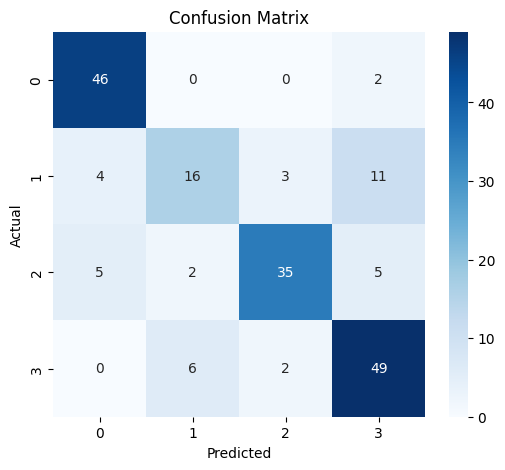

In [41]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Blance Data

In [43]:
from imblearn.over_sampling import SMOTE

smote = SMOTE( random_state=42, k_neighbors=5 )

X_balanced, y_balanced = smote.fit_resample(X, y)
from collections import Counter

print(Counter(y_balanced))


Counter({np.int64(0): 284, np.int64(1): 284, np.int64(2): 284, np.int64(3): 284})


In [44]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

test13

before balnce
 Accuracy on Training: 1.0
 Accuracy  on Test: 0.9623655913978495

In [46]:
model=RandomForestClassifier(n_estimators=300,max_depth=20, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 1.0
 Accuracy  on Test: 0.9623655913978495


test14

before balnce
 Accuracy on Training: 1.0
 Accuracy  on Test: 0.9516129032258065

In [48]:
model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 1.0
 Accuracy  on Test: 0.9516129032258065


test13

In [49]:
model=RandomForestClassifier(n_estimators=300,max_depth=20, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(" Accuracy on Training:", model.score(X_train, y_train))
print(" Accuracy  on Test:", model.score(X_test, y_test))

 Accuracy on Training: 1.0
 Accuracy  on Test: 0.9623655913978495



Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       0.97      1.00      0.99        34
           2       0.95      0.89      0.92        47
           3       0.93      0.96      0.95        57

    accuracy                           0.96       186
   macro avg       0.96      0.96      0.96       186
weighted avg       0.96      0.96      0.96       186


Confusion Matrix:
 [[48  0  0  0]
 [ 0 34  0  0]
 [ 0  1 42  4]
 [ 0  0  2 55]]


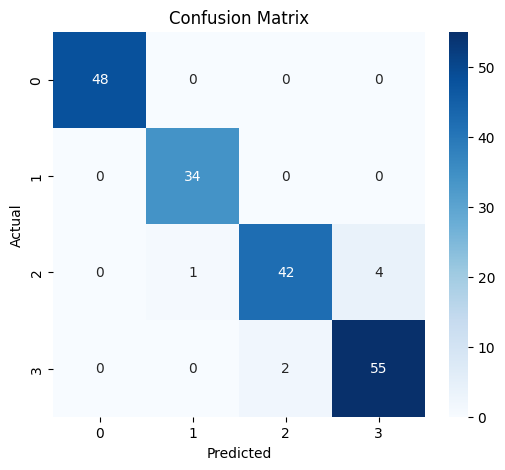

In [50]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [51]:
from joblib import dump, load


dump(model, 'random_forest_ecg_model.joblib')


loaded_model = load('random_forest_ecg_model.joblib')

y_pred_loaded = loaded_model.predict(X_test)
print("Accuracy with loaded model:", loaded_model.score(X_test, y_test))


Accuracy with loaded model: 0.9623655913978495
